In [1]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import skew
from scipy.stats import boxcox
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.impute import SimpleImputer
import shap
%matplotlib inline


/Users/tarikbilgindemirci/Desktop/MLPractice/algorithms/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# RESEARCH QUESTIONS
"""
RQ1: How does increasing missing-data severity affect the predictive performance of AI-based air-quality monitoring systems?
Experiment:
Clean data
10% missing
20% missing
30% missing
40% missing
Metrics:
RMSE
MAE
R²
Figure:
Performance degradation curve
Table:
Performance matrix

RQ2: Which machine-learning models exhibit the greatest robustness under increasing levels of missing environmental sensor data?
Models:
Linear Regression
Random Forest
XGBoost
Gradient Boosting
Figure:
Robustness comparison chart
Table:
Average degradation percentage

RQ3: How resilient are air-quality prediction models to sensor noise and measurement uncertainty?
Experiment:
Add Gaussian noise:
5%
10%
15%
20%
Figure:
Noise vs RMSE
Table:
Model robustness scores

RQ4: Do explanations produced by feature-importance methods remain stable when environmental data quality deteriorates?
Method:
Train on clean data
Train on noisy data
Compare SHAP rankings
Figure:
SHAP summary plots
Table:
Top features under each condition
Possible finding:
The model remains accurate but explanations become unstable.
This is a strong governance-related result.

RQ5: Can data-quality mitigation strategies restore trustworthiness under severe data degradation?
Strategies:
Mean Imputation
KNN Imputation
Iterative Imputation
Evaluate:
Recovery in RMSE
Recovery in R²
Figure:
Performance recovery chart
Table:
"""


'\nRQ1: How does increasing missing-data severity affect the predictive performance of AI-based air-quality monitoring systems?\nExperiment:\nClean data\n10% missing\n20% missing\n30% missing\n40% missing\nMetrics:\nRMSE\nMAE\nR²\nFigure:\nPerformance degradation curve\nTable:\nPerformance matrix\n\nRQ2: Which machine-learning models exhibit the greatest robustness under increasing levels of missing environmental sensor data?\nModels:\nLinear Regression\nRandom Forest\nXGBoost\nGradient Boosting\nFigure:\nRobustness comparison chart\nTable:\nAverage degradation percentage\n\nRQ3: How resilient are air-quality prediction models to sensor noise and measurement uncertainty?\nExperiment:\nAdd Gaussian noise:\n5%\n10%\n15%\n20%\nFigure:\nNoise vs RMSE\nTable:\nModel robustness scores\n\nRQ4: Do explanations produced by feature-importance methods remain stable when environmental data quality deteriorates?\nMethod:\nTrain on clean data\nTrain on noisy data\nCompare SHAP rankings\nFigure:\nSHA

In [3]:
df = pd.read_csv("AirQualityUCI.csv")

In [4]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,NaN,NaN
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,NaN,NaN
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,NaN,NaN
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,NaN,NaN
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,NaN,NaN


In [5]:
df["Unnamed: 16"].value_counts()

Series([], Name: count, dtype: int64)

In [6]:
df = df.drop(columns=["Unnamed: 15", "Unnamed: 16"])

In [7]:
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), str(2)
memory usage: 1.1 MB


In [9]:
df.isnull().sum()

Date             114
Time             114
CO(GT)           114
PT08.S1(CO)      114
NMHC(GT)         114
C6H6(GT)         114
PT08.S2(NMHC)    114
NOx(GT)          114
PT08.S3(NOx)     114
NO2(GT)          114
PT08.S4(NO2)     114
PT08.S5(O3)      114
T                114
RH               114
AH               114
dtype: int64

In [10]:
(df == -200).sum()

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

In [11]:
df["NMHC(GT)"].value_counts()

NMHC(GT)
-200.0    8443
 66.0       14
 29.0        9
 40.0        9
 88.0        8
          ... 
 344.0       1
 265.0       1
 365.0       1
 642.0       1
 501.0       1
Name: count, Length: 430, dtype: int64

In [12]:
df["CO(GT)"].value_counts()

CO(GT)
-200.0    1683
 1.0       305
 1.4       279
 1.6       275
 1.5       273
          ... 
 10.1        1
 9.4         1
 9.9         1
 9.3         1
 8.5         1
Name: count, Length: 97, dtype: int64

In [13]:
def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

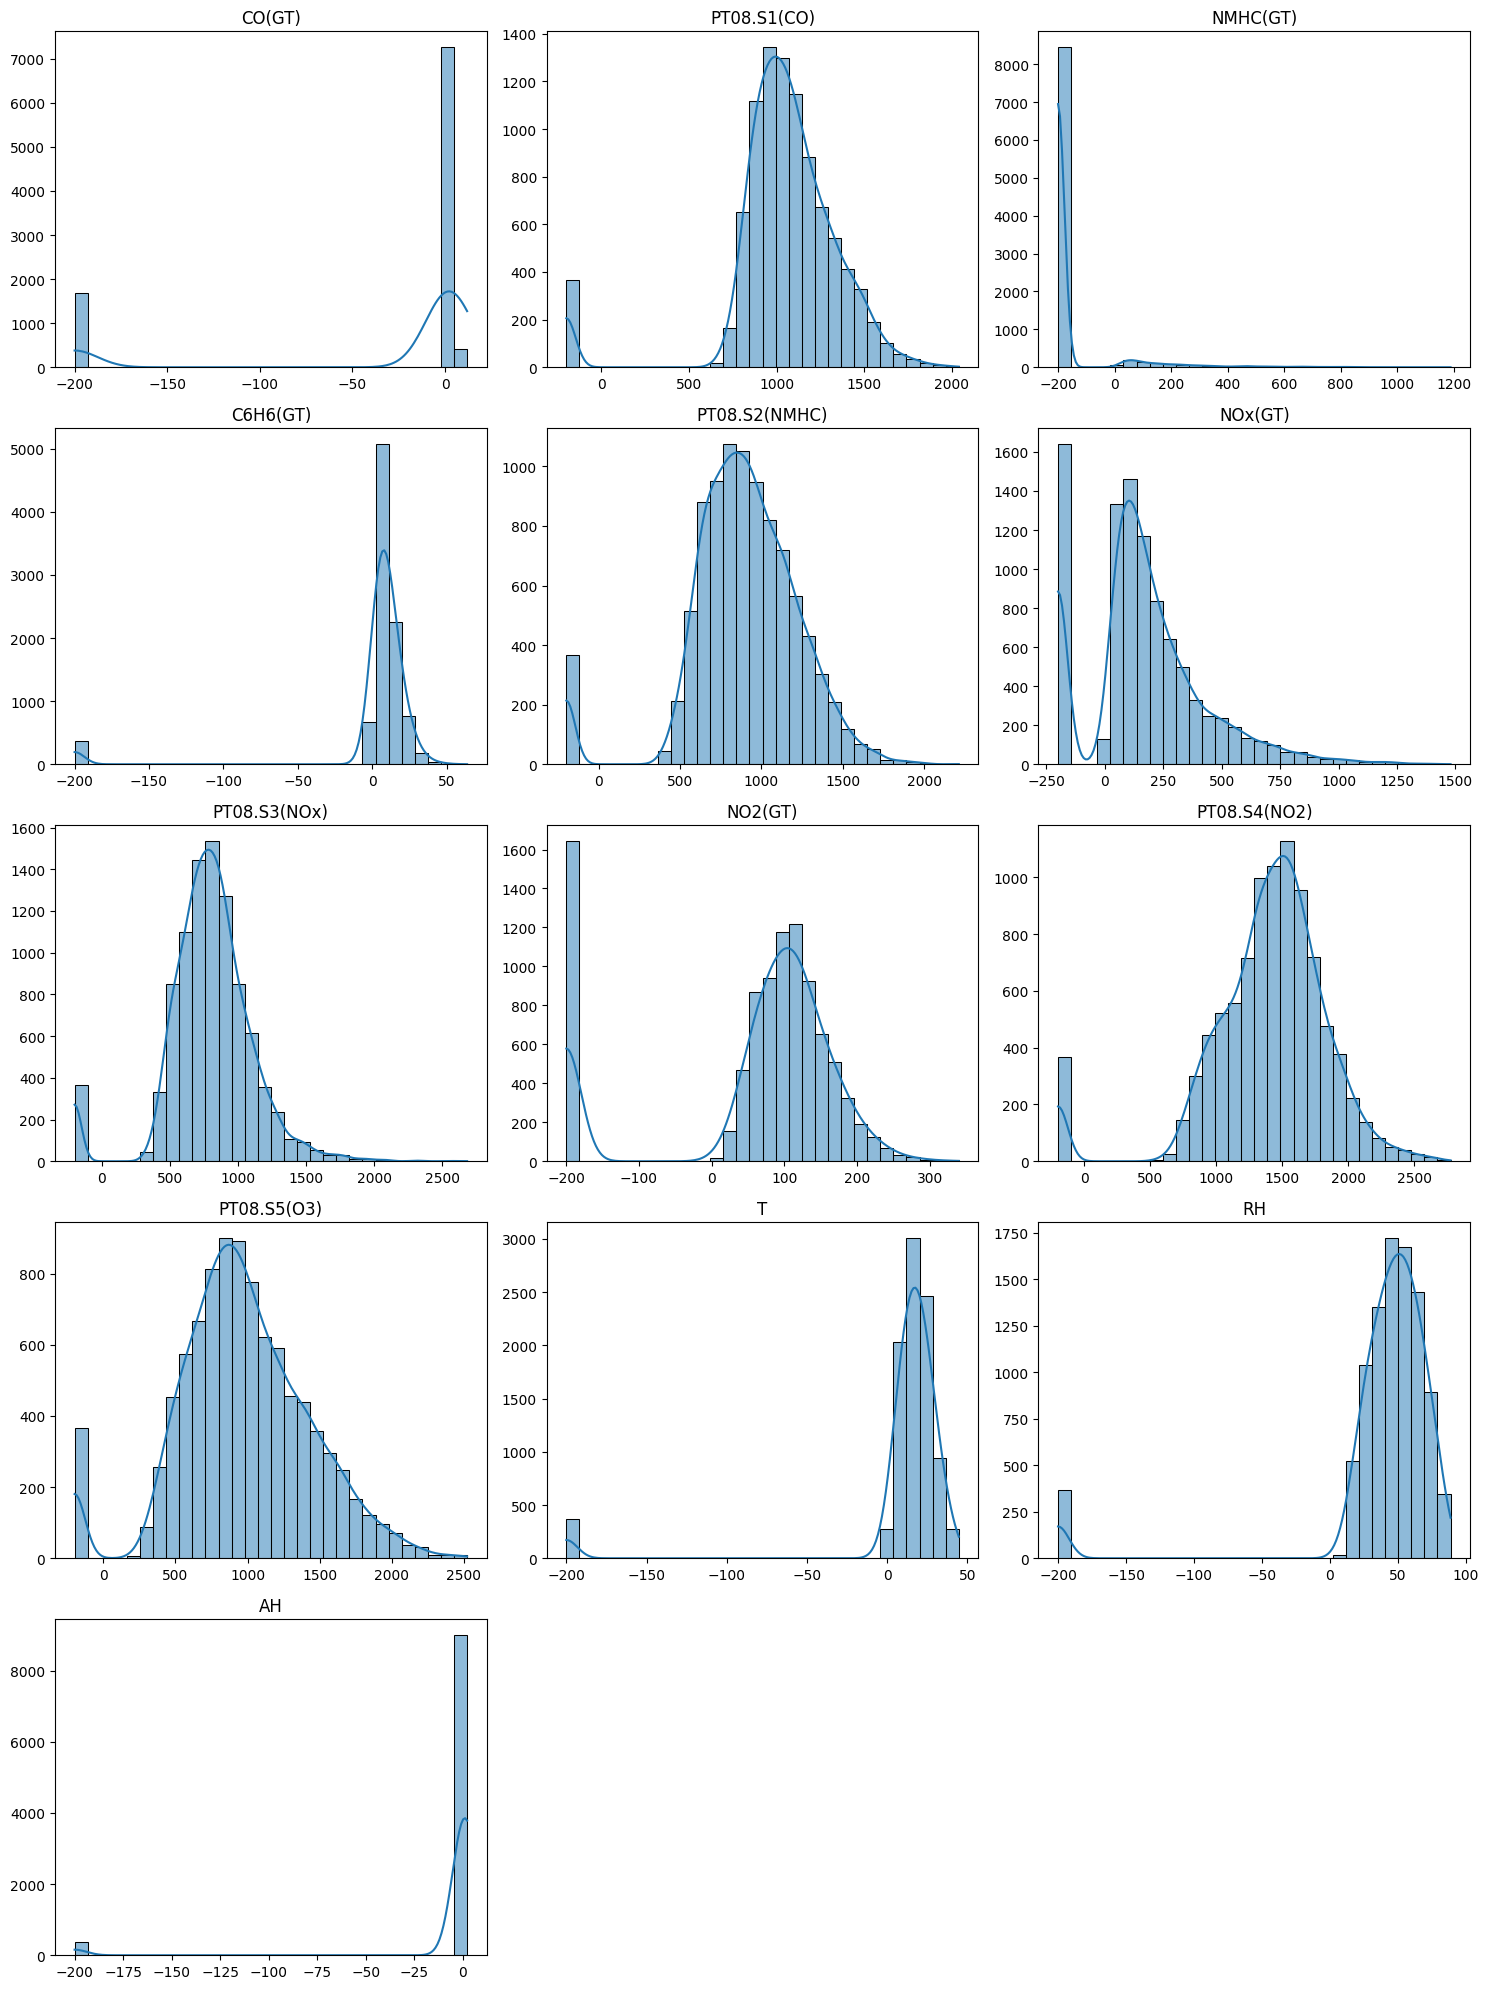

In [14]:
plot_all_histograms(df,title_prefix="")

In [15]:
df = df.replace(-200, np.nan)

In [16]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

missing_summary = missing_summary.sort_values(
    "Missing Percentage",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
NMHC(GT),8557,90.349488
CO(GT),1797,18.973709
NO2(GT),1756,18.540809
NOx(GT),1753,18.509133
PT08.S1(CO),480,5.068103
C6H6(GT),480,5.068103
PT08.S2(NMHC),480,5.068103
PT08.S3(NOx),480,5.068103
PT08.S4(NO2),480,5.068103
PT08.S5(O3),480,5.068103


In [17]:
df = df.drop(columns=["NMHC(GT)"])

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         7674 non-null   float64
 3   PT08.S1(CO)    8991 non-null   float64
 4   C6H6(GT)       8991 non-null   float64
 5   PT08.S2(NMHC)  8991 non-null   float64
 6   NOx(GT)        7718 non-null   float64
 7   PT08.S3(NOx)   8991 non-null   float64
 8   NO2(GT)        7715 non-null   float64
 9   PT08.S4(NO2)   8991 non-null   float64
 10  PT08.S5(O3)    8991 non-null   float64
 11  T              8991 non-null   float64
 12  RH             8991 non-null   float64
 13  AH             8991 non-null   float64
dtypes: float64(12), str(2)
memory usage: 1.0 MB


In [19]:
print(df["Date"].head())
print(df["Time"].head())

0    3/10/2004
1    3/10/2004
2    3/10/2004
3    3/10/2004
4    3/10/2004
Name: Date, dtype: str
0    18:00:00
1    19:00:00
2    20:00:00
3    21:00:00
4    22:00:00
Name: Time, dtype: str


In [20]:
print(df["Date"].dtype)
print(df["Time"].dtype)

str
str


In [21]:
df["DateTime"] = pd.to_datetime(
    df["Date"] + " " + df["Time"],
    errors="coerce"
)

In [22]:
df["DateTime"].isna().sum()

np.int64(114)

In [23]:
df["Hour"] = df["DateTime"].dt.hour
df["Month"] = df["DateTime"].dt.month
df["DayOfWeek"] = df["DateTime"].dt.dayofweek
df["Weekend"] = (df["DayOfWeek"] >= 5).astype(int)

In [24]:
df[["Hour","DayOfWeek","Month","Weekend"]].head()

,Hour,DayOfWeek,Month,Weekend
0,18.0,2.0,3.0,0
1,19.0,2.0,3.0,0
2,20.0,2.0,3.0,0
3,21.0,2.0,3.0,0
4,22.0,2.0,3.0,0


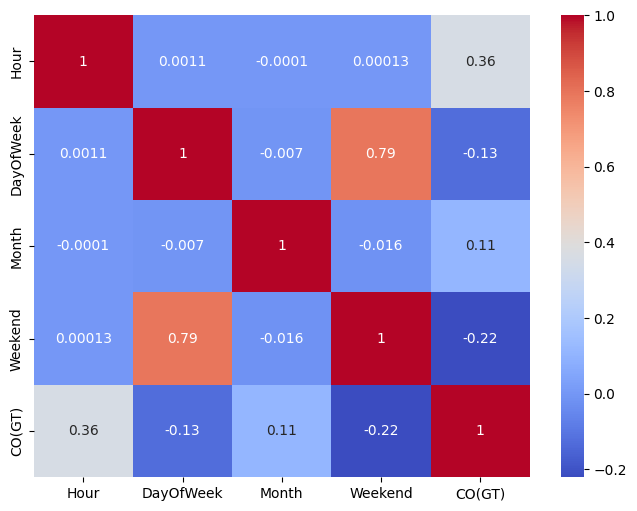

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Hour","DayOfWeek","Month","Weekend","CO(GT)"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   str           
 1   Time           9357 non-null   str           
 2   CO(GT)         7674 non-null   float64       
 3   PT08.S1(CO)    8991 non-null   float64       
 4   C6H6(GT)       8991 non-null   float64       
 5   PT08.S2(NMHC)  8991 non-null   float64       
 6   NOx(GT)        7718 non-null   float64       
 7   PT08.S3(NOx)   8991 non-null   float64       
 8   NO2(GT)        7715 non-null   float64       
 9   PT08.S4(NO2)   8991 non-null   float64       
 10  PT08.S5(O3)    8991 non-null   float64       
 11  T              8991 non-null   float64       
 12  RH             8991 non-null   float64       
 13  AH             8991 non-null   float64       
 14  DateTime       9357 non-null   datetime64[us]
 15  Hour           9357 non-null   f

In [27]:
df.drop(
    columns=["Date", "Time", "DateTime"],
    inplace=True
)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   C6H6(GT)       8991 non-null   float64
 3   PT08.S2(NMHC)  8991 non-null   float64
 4   NOx(GT)        7718 non-null   float64
 5   PT08.S3(NOx)   8991 non-null   float64
 6   NO2(GT)        7715 non-null   float64
 7   PT08.S4(NO2)   8991 non-null   float64
 8   PT08.S5(O3)    8991 non-null   float64
 9   T              8991 non-null   float64
 10  RH             8991 non-null   float64
 11  AH             8991 non-null   float64
 12  Hour           9357 non-null   float64
 13  Month          9357 non-null   float64
 14  DayOfWeek      9357 non-null   float64
 15  Weekend        9471 non-null   int64  
dtypes: float64(15), int64(1)
memory usage: 1.2 MB


In [29]:
y = df["CO(GT)"]
X = df.drop(columns=["CO(GT)"])

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
X_train.isnull().sum().sort_values(ascending=False)

NO2(GT)          1427
NOx(GT)          1424
PT08.S1(CO)       390
C6H6(GT)          390
PT08.S2(NMHC)     390
PT08.S3(NOx)      390
PT08.S4(NO2)      390
PT08.S5(O3)       390
T                 390
RH                390
AH                390
Hour               92
Month              92
DayOfWeek          92
Weekend             0
dtype: int64

In [32]:
(X_train.isnull().mean()*100).sort_values(ascending=False)

NO2(GT)          18.835797
NOx(GT)          18.796199
PT08.S1(CO)       5.147835
C6H6(GT)          5.147835
PT08.S2(NMHC)     5.147835
PT08.S3(NOx)      5.147835
PT08.S4(NO2)      5.147835
PT08.S5(O3)       5.147835
T                 5.147835
RH                5.147835
AH                5.147835
Hour              1.214361
Month             1.214361
DayOfWeek         1.214361
Weekend           0.000000
dtype: float64

In [33]:
y_train.isnull().sum()

np.int64(1466)

In [34]:
y_test.isnull().sum()

np.int64(331)

In [35]:
df["CO(GT)"].isnull().sum()

np.int64(1797)

In [36]:
df = df.dropna(subset=["CO(GT)"])

In [37]:
y = df["CO(GT)"]
X = df.drop(columns=["CO(GT)"])

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [38]:
y_train.isnull().sum()

np.int64(0)

In [39]:
y_test.isnull().sum()

np.int64(0)

In [40]:
(X_train.isnull().mean()*100).sort_values(ascending=False)

NO2(GT)          5.342890
NOx(GT)          5.294022
PT08.S1(CO)      4.300375
C6H6(GT)         4.300375
PT08.S2(NMHC)    4.300375
PT08.S3(NOx)     4.300375
PT08.S4(NO2)     4.300375
PT08.S5(O3)      4.300375
T                4.300375
RH               4.300375
AH               4.300375
Hour             0.000000
Month            0.000000
DayOfWeek        0.000000
Weekend          0.000000
dtype: float64

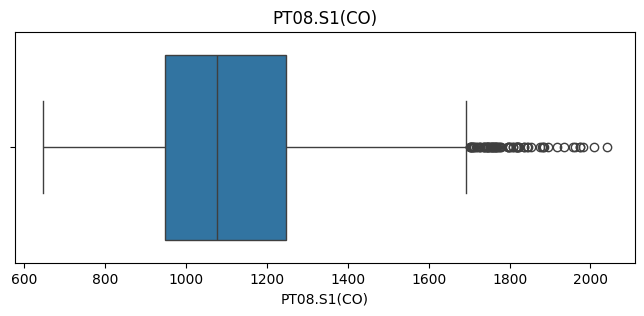

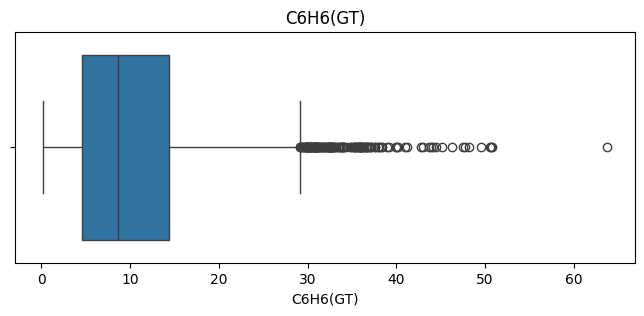

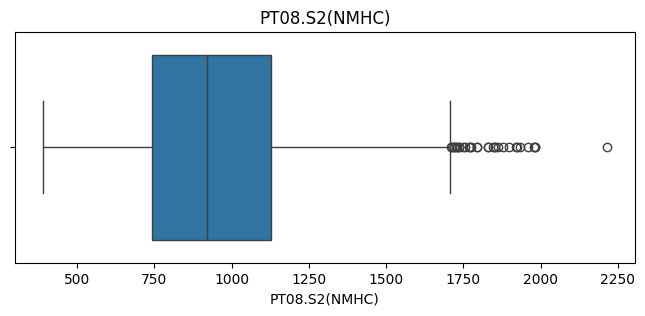

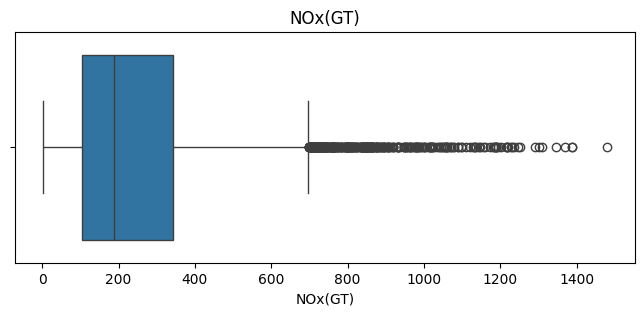

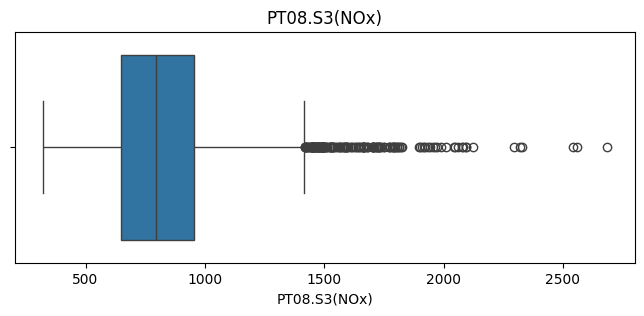

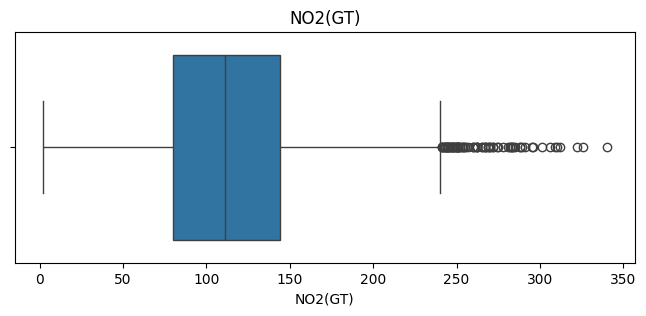

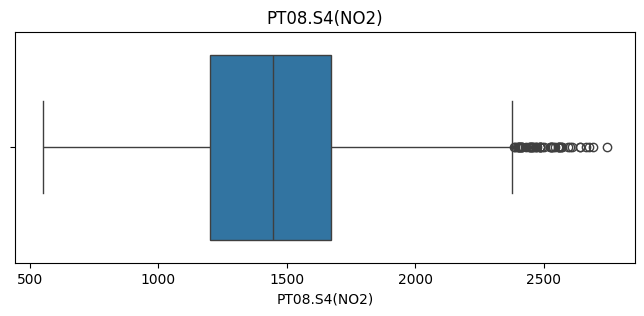

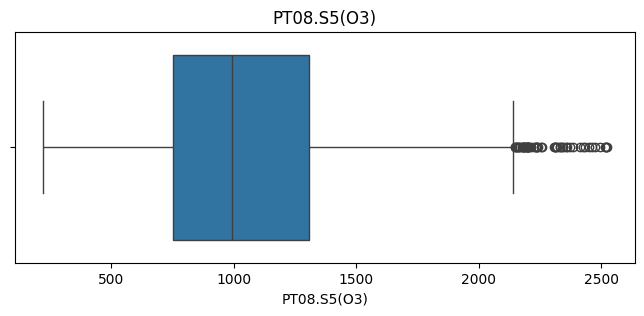

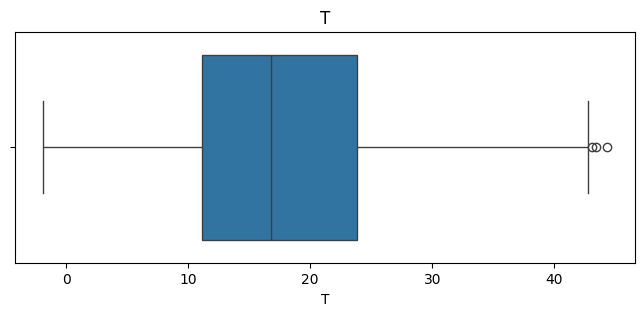

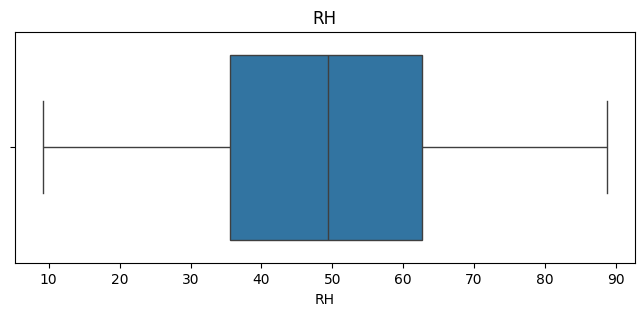

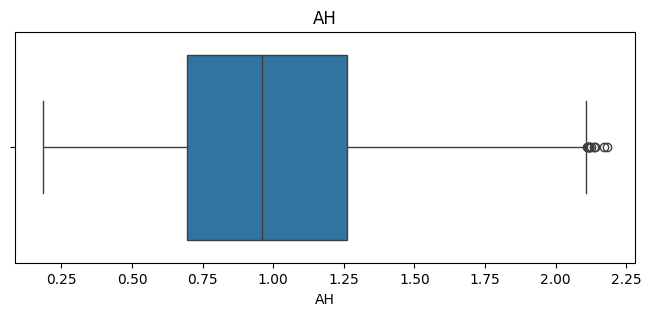

In [41]:
missing_cols = X_train.columns[X_train.isnull().any()]

for col in missing_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=X_train[col])
    plt.title(col)
    plt.show()

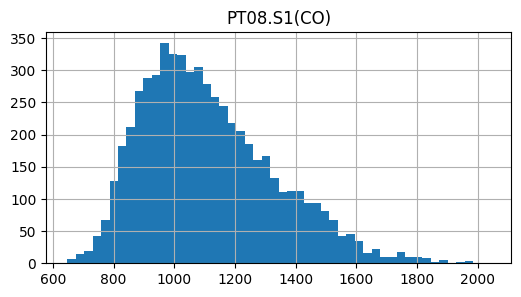

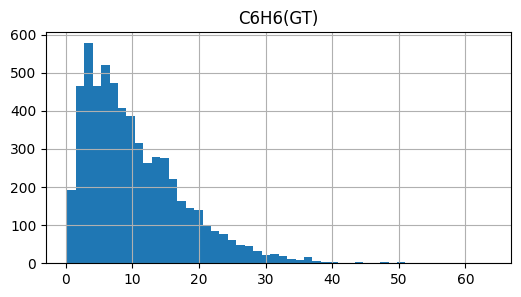

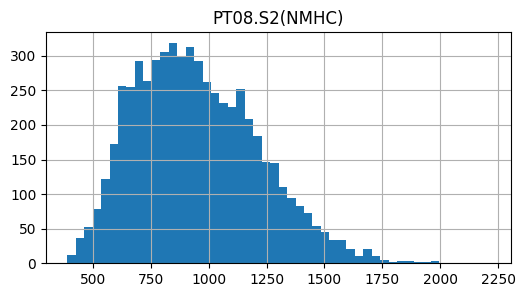

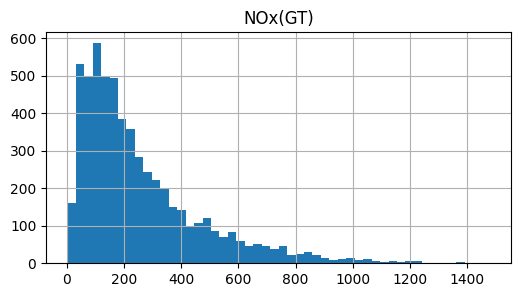

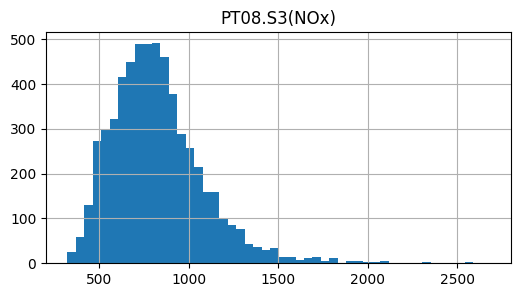

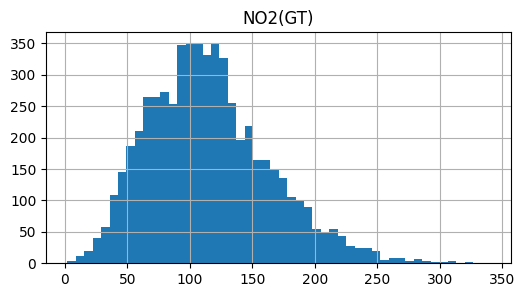

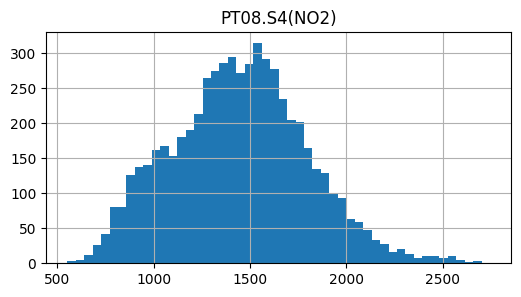

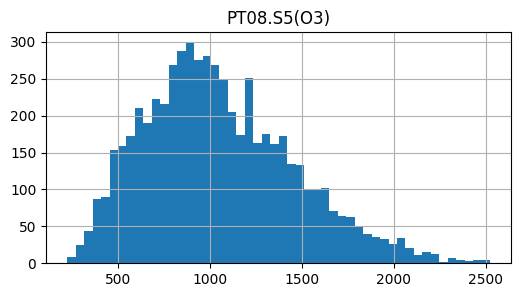

In [42]:
cols = [
    "PT08.S1(CO)",
    "C6H6(GT)",
    "PT08.S2(NMHC)",
    "NOx(GT)",
    "PT08.S3(NOx)",
    "NO2(GT)",
    "PT08.S4(NO2)",
    "PT08.S5(O3)"
]

for col in cols:
    plt.figure(figsize=(6,3))
    X_train[col].hist(bins=50)
    plt.title(col)
    plt.show()

In [43]:
for col in cols:
    print(col, X_train[col].skew())

PT08.S1(CO) 0.7277025808793314
C6H6(GT) 1.3125439196129118
PT08.S2(NMHC) 0.5228454208337766
NOx(GT) 1.6639055980456805
PT08.S3(NOx) 1.2349666292405952
NO2(GT) 0.6288117024918678
PT08.S4(NO2) 0.21549427637726276
PT08.S5(O3) 0.5792594577849046


In [44]:
#Since several environmental variables exhibited skewed distributions and substantial outliers, median imputation was selected as the baseline strategy due to its robustness against extreme observations.

median_imputer = SimpleImputer(strategy="median")

X_train_base = median_imputer.fit_transform(X_train)
X_test_base = median_imputer.transform(X_test)

In [45]:
print(np.isnan(X_train_base).sum())
print(np.isnan(X_test_base).sum())

0
0


In [46]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

In [47]:
results = []

for name, model in models.items():

    model.fit(X_train_base, y_train)

    predictions = model.predict(X_test_base)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append([
        name,
        rmse,
        mae,
        r2
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "RMSE",
        "MAE",
        "R2"
    ]
)

results_df

,Model,RMSE,MAE,R2
0,Linear Regression,0.468130,0.305252,0.894787
1,Random Forest,0.360937,0.226554,0.937454
2,Gradient Boosting,0.379296,0.243795,0.930929


In [48]:
# Because the selected machine-learning models cannot be trained directly with missing values, 
# artificial missingness was introduced first and then handled using median imputation. 
# Therefore, the performance degradation reflects the information loss caused by missing data, not a failure to run the model.
def introduce_missingness(df, missing_rate, random_state=42):

    df_missing = df.copy()

    np.random.seed(random_state)

    mask = np.random.rand(*df_missing.shape) < missing_rate

    df_missing = df_missing.mask(mask)

    return df_missing

In [49]:
missing_rates = [0.10, 0.20, 0.30, 0.40]

rq1_results = []

for rate in missing_rates:
    
    X_train_missing = introduce_missingness(
        X_train,
        missing_rate=rate,
        random_state=42
    )
    
    imputer = SimpleImputer(strategy="median")
    
    X_train_imp = imputer.fit_transform(X_train_missing)
    X_test_imp = imputer.transform(X_test)
    
    for name, model in models.items():
        
        model.fit(X_train_imp, y_train)
        predictions = model.predict(X_test_imp)
        
        rmse = np.sqrt(mean_squared_error(y_test, predictions))
        mae = mean_absolute_error(y_test, predictions)
        r2 = r2_score(y_test, predictions)
        
        rq1_results.append([
            int(rate * 100),
            name,
            rmse,
            mae,
            r2
        ])

In [50]:
rq1_results_df = pd.DataFrame(
    rq1_results,
    columns=["Missing Percentage", "Model", "RMSE", "MAE", "R2"]
)

rq1_results_df

,Missing Percentage,Model,RMSE,MAE,R2
0,10,Linear Regression,0.490153,0.326927,0.884655
1,10,Random Forest,0.377885,0.238771,0.931442
2,10,Gradient Boosting,0.391991,0.256477,0.926228
3,20,Linear Regression,0.541204,0.385279,0.859376
4,20,Random Forest,0.390798,0.247960,0.926677
5,20,Gradient Boosting,0.408417,0.275375,0.919916
6,30,Linear Regression,0.640097,0.482187,0.803289
7,30,Random Forest,0.395172,0.255644,0.925026
8,30,Gradient Boosting,0.432737,0.300243,0.910095
9,40,Linear Regression,0.803337,0.629638,0.690164


In [51]:
# RQ1: How does increasing missing-data severity affect the predictive performance of AI-based air-quality monitoring systems?
baseline_results_df = results_df.copy()
baseline_results_df["Missing Percentage"] = 0

baseline_results_df = baseline_results_df[
    ["Missing Percentage", "Model", "RMSE", "MAE", "R2"]
]

rq1_full_results_df = pd.concat(
    [baseline_results_df, rq1_results_df],
    ignore_index=True
)

rq1_full_results_df

,Missing Percentage,Model,RMSE,MAE,R2
0,0,Linear Regression,0.468130,0.305252,0.894787
1,0,Random Forest,0.360937,0.226554,0.937454
2,0,Gradient Boosting,0.379296,0.243795,0.930929
3,10,Linear Regression,0.490153,0.326927,0.884655
4,10,Random Forest,0.377885,0.238771,0.931442
5,10,Gradient Boosting,0.391991,0.256477,0.926228
6,20,Linear Regression,0.541204,0.385279,0.859376
7,20,Random Forest,0.390798,0.247960,0.926677
8,20,Gradient Boosting,0.408417,0.275375,0.919916
9,30,Linear Regression,0.640097,0.482187,0.803289


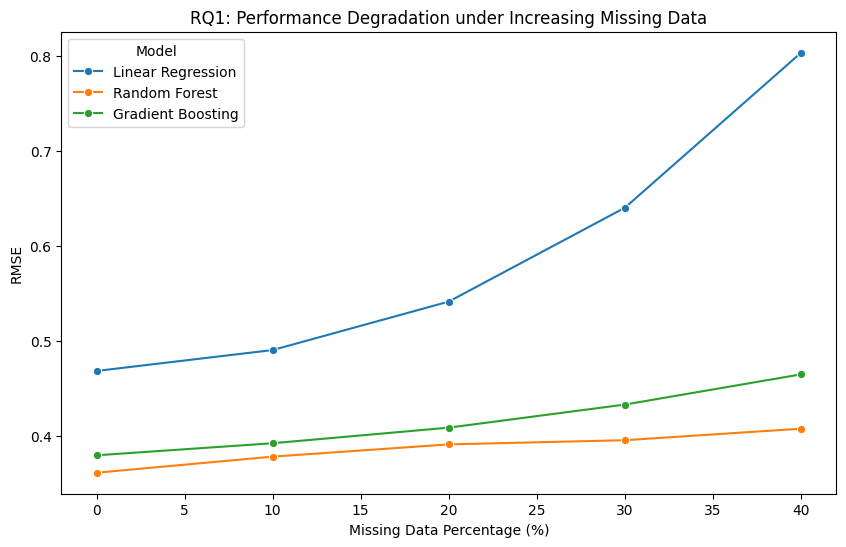

In [52]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=rq1_full_results_df,
    x="Missing Percentage",
    y="RMSE",
    hue="Model",
    marker="o"
)

plt.title("RQ1: Performance Degradation under Increasing Missing Data")
plt.xlabel("Missing Data Percentage (%)")
plt.ylabel("RMSE")
plt.show()

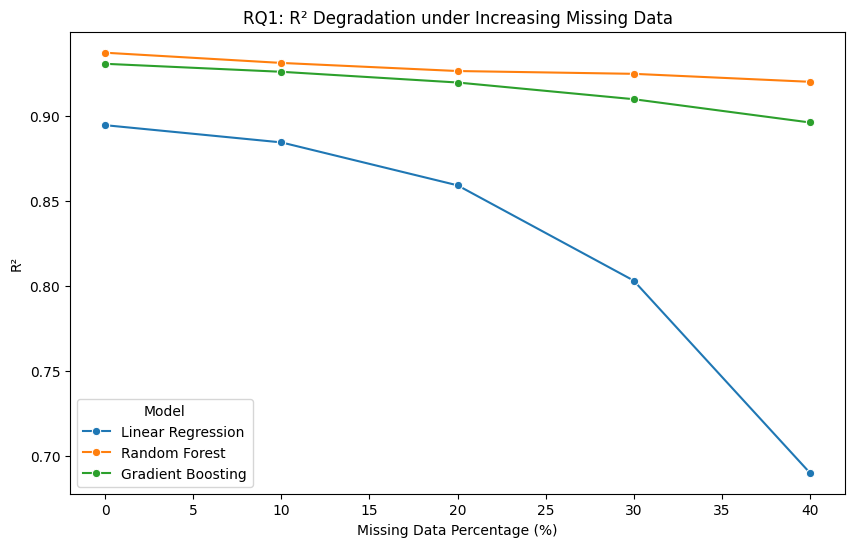

In [53]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=rq1_full_results_df,
    x="Missing Percentage",
    y="R2",
    hue="Model",
    marker="o"
)

plt.title("RQ1: R² Degradation under Increasing Missing Data")
plt.xlabel("Missing Data Percentage (%)")
plt.ylabel("R²")
plt.show()

In [54]:
"""
Increasing levels of missing data consistently reduced prediction performance across all models. 
However, tree-based models demonstrated considerably greater resilience than Linear Regression.
Even under 40% missingness, Random Forest maintained an R² above 0.92, whereas Linear Regression dropped below 0.70.
"""

'\nIncreasing levels of missing data consistently reduced prediction performance across all models. \nHowever, tree-based models demonstrated considerably greater resilience than Linear Regression.\nEven under 40% missingness, Random Forest maintained an R² above 0.92, whereas Linear Regression dropped below 0.70.\n'

In [55]:
baseline = rq1_full_results_df[
    rq1_full_results_df["Missing Percentage"] == 0
]

missing40 = rq1_full_results_df[
    rq1_full_results_df["Missing Percentage"] == 40
]

In [56]:
robustness_results = []

for model in baseline["Model"]:

    baseline_r2 = baseline[
        baseline["Model"] == model
    ]["R2"].values[0]

    missing_r2 = missing40[
        missing40["Model"] == model
    ]["R2"].values[0]

    degradation = (
        (baseline_r2 - missing_r2)
        / baseline_r2
    ) * 100

    robustness_results.append([
        model,
        baseline_r2,
        missing_r2,
        degradation
    ])

In [57]:
robustness_df = pd.DataFrame(
    robustness_results,
    columns=[
        "Model",
        "Baseline R2",
        "40% Missing R2",
        "Performance Degradation (%)"
    ]
)

robustness_df

,Model,Baseline R2,40% Missing R2,Performance Degradation (%)
0,Linear Regression,0.894787,0.690164,22.868304
1,Random Forest,0.937454,0.920338,1.825861
2,Gradient Boosting,0.930929,0.896393,3.709895


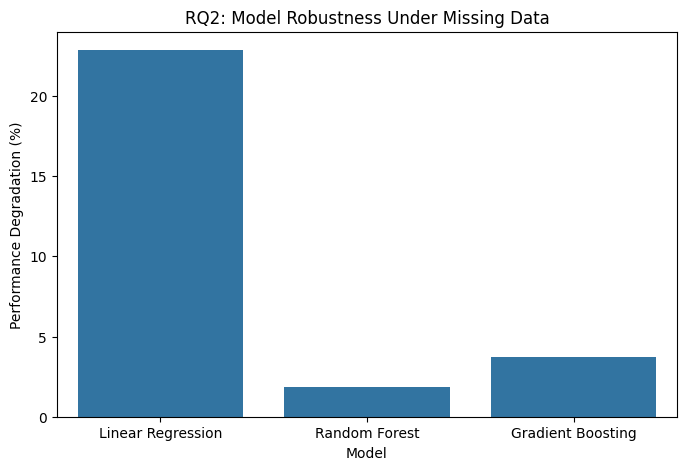

In [58]:
#RQ2: Which machine-learning models exhibit the greatest robustness under increasing levels of missing environmental sensor data?
plt.figure(figsize=(8,5))

sns.barplot(
    data=robustness_df,
    x="Model",
    y="Performance Degradation (%)"
)

plt.title(
    "RQ2: Model Robustness Under Missing Data"
)

plt.ylabel(
    "Performance Degradation (%)"
)

plt.show()

In [59]:
"""
RQ2: Which machine-learning models exhibit the greatest robustness under increasing levels of missing environmental sensor data?
Random Forest exhibited the highest robustness under increasing missing-data severity, 
showing only a minimal reduction in predictive performance. Gradient Boosting also demonstrated strong resilience, 
whereas Linear Regression experienced substantial degradation. 
These findings suggest that tree-based ensemble methods are significantly more tolerant to information loss than linear models.
"""

'\nRQ2: Which machine-learning models exhibit the greatest robustness under increasing levels of missing environmental sensor data?\nRandom Forest exhibited the highest robustness under increasing missing-data severity, \nshowing only a minimal reduction in predictive performance. Gradient Boosting also demonstrated strong resilience, \nwhereas Linear Regression experienced substantial degradation. \nThese findings suggest that tree-based ensemble methods are significantly more tolerant to information loss than linear models.\n'

In [60]:
def add_gaussian_noise(df, noise_level, random_state=42):

    np.random.seed(random_state)

    noisy_df = df.copy()

    numeric_cols = noisy_df.select_dtypes(
        include=np.number
    ).columns

    noise = np.random.normal(
        loc=0,
        scale=noise_level,
        size=noisy_df[numeric_cols].shape
    )

    noisy_df[numeric_cols] = (
        noisy_df[numeric_cols]
        + noisy_df[numeric_cols] * noise
    )

    return noisy_df

In [61]:
noise_levels = [0.05, 0.10, 0.15, 0.20]

rq3_results = []

for level in noise_levels:

    X_train_noisy = add_gaussian_noise(
        pd.DataFrame(X_train_base),
        noise_level=level
    )

    for name, model in models.items():

        model.fit(
            X_train_noisy,
            y_train
        )

        predictions = model.predict(
            X_test_base
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        r2 = r2_score(
            y_test,
            predictions
        )

        rq3_results.append([
            int(level * 100),
            name,
            rmse,
            mae,
            r2
        ])

In [62]:

rq3_results_df = pd.DataFrame(
    rq3_results,
    columns=[
        "Noise Percentage",
        "Model",
        "RMSE",
        "MAE",
        "R2"
    ]
)

rq3_results_df

,Noise Percentage,Model,RMSE,MAE,R2
0,5,Linear Regression,0.474675,0.302161,0.891825
1,5,Random Forest,0.375587,0.233670,0.932274
2,5,Gradient Boosting,0.381513,0.243959,0.930120
3,10,Linear Regression,0.487741,0.307703,0.885787
4,10,Random Forest,0.394801,0.246765,0.925167
5,10,Gradient Boosting,0.400775,0.253907,0.922885
6,15,Linear Regression,0.499883,0.316561,0.880030
7,15,Random Forest,0.415855,0.257158,0.916973
8,15,Gradient Boosting,0.423663,0.269727,0.913826
9,20,Linear Regression,0.511925,0.326518,0.874180


In [63]:
#RQ3: How resilient are air-quality prediction models to sensor noise and measurement uncertainty?
baseline_noise = results_df.copy()

baseline_noise["Noise Percentage"] = 0

baseline_noise = baseline_noise[
    [
        "Noise Percentage",
        "Model",
        "RMSE",
        "MAE",
        "R2"
    ]
]

rq3_full_results_df = pd.concat(
    [baseline_noise, rq3_results_df],
    ignore_index=True
)

rq3_full_results_df = rq3_full_results_df.sort_values(
    ["Model", "Noise Percentage"]
)

rq3_full_results_df

,Noise Percentage,Model,RMSE,MAE,R2
2,0,Gradient Boosting,0.379296,0.243795,0.930929
5,5,Gradient Boosting,0.381513,0.243959,0.930120
8,10,Gradient Boosting,0.400775,0.253907,0.922885
11,15,Gradient Boosting,0.423663,0.269727,0.913826
14,20,Gradient Boosting,0.446802,0.284167,0.904156
0,0,Linear Regression,0.468130,0.305252,0.894787
3,5,Linear Regression,0.474675,0.302161,0.891825
6,10,Linear Regression,0.487741,0.307703,0.885787
9,15,Linear Regression,0.499883,0.316561,0.880030
12,20,Linear Regression,0.511925,0.326518,0.874180


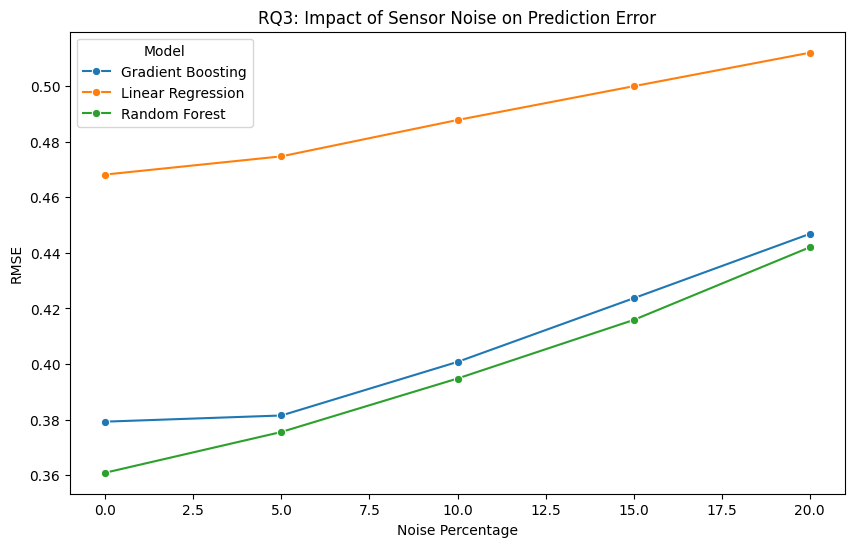

In [64]:
#RQ3: How resilient are air-quality prediction models to sensor noise and measurement uncertainty?
plt.figure(figsize=(10,6))

sns.lineplot(
    data=rq3_full_results_df,
    x="Noise Percentage",
    y="RMSE",
    hue="Model",
    marker="o"
)

plt.title(
    "RQ3: Impact of Sensor Noise on Prediction Error"
)

plt.show()

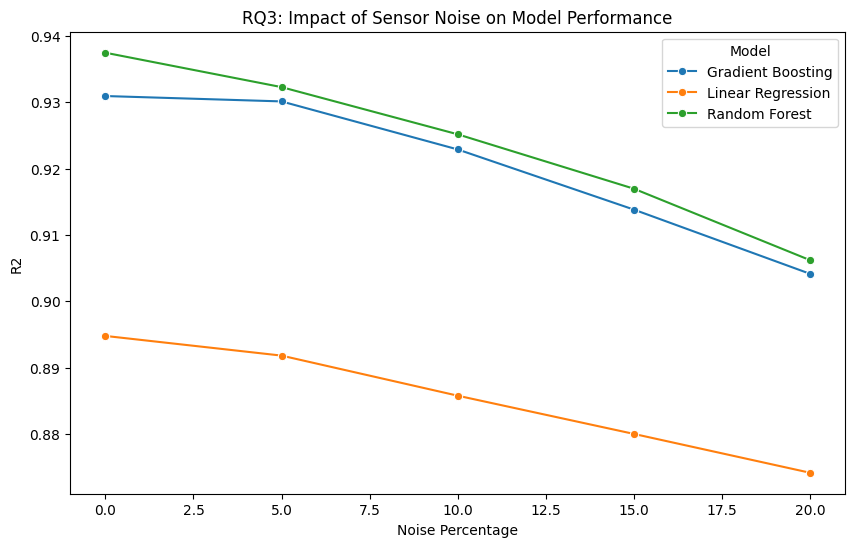

In [65]:
#RQ3: How resilient are air-quality prediction models to sensor noise and measurement uncertainty?
plt.figure(figsize=(10,6))

sns.lineplot(
    data=rq3_full_results_df,
    x="Noise Percentage",
    y="R2",
    hue="Model",
    marker="o"
)

plt.title(
    "RQ3: Impact of Sensor Noise on Model Performance"
)

plt.show()

In [66]:
# Missing data causes substantially larger performance degradation than moderate sensor noise.

In [68]:
# RQ4: Do explanations produced by feature-importance methods remain stable when environmental data quality deteriorates?
best_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

best_model.fit(
    X_train_base,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
"""
SHAP (SHapley Additive exPlanations) is an explainable AI technique used to interpret machine-learning models. 
It quantifies the contribution of each feature to a model’s prediction based on Shapley values from cooperative game theory. 
In this study, SHAP is used to identify the most influential environmental variables affecting air-quality predictions 
    and to investigate whether feature importance rankings remain stable when data quality deteriorates.
"""
explainer = shap.TreeExplainer(
    best_model
)

In [70]:
X_sample = pd.DataFrame(
    X_test_base,
    columns=X_train.columns
).sample(
    500,
    random_state=42
)

In [71]:
shap_values = explainer.shap_values(
    X_sample
)

/var/folders/7v/m7720v711bqcp2xfhvznls9w0000gn/T/ipykernel_16419/1101180912.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


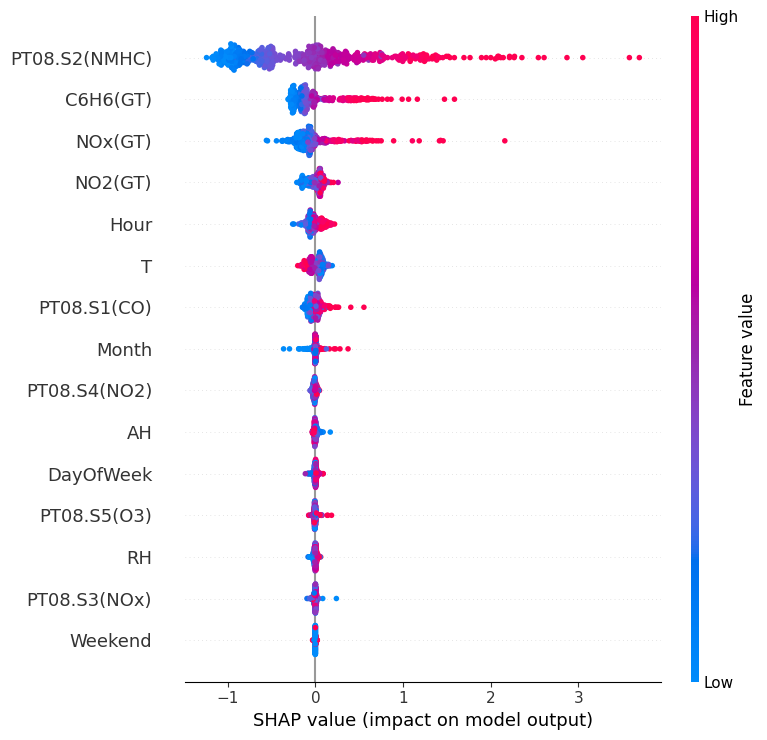

In [72]:
shap.summary_plot(
    shap_values,
    X_sample
)

In [75]:
X_train_noisy = add_gaussian_noise(
    pd.DataFrame(
        X_train_base,
        columns=X_train.columns
    ),
    noise_level=0.20
)

In [76]:
rf_noisy = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_noisy.fit(
    X_train_noisy,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [77]:
explainer_noisy = shap.TreeExplainer(
    rf_noisy
)

In [78]:
shap_values_noisy = explainer_noisy.shap_values(
    X_sample
)

/var/folders/7v/m7720v711bqcp2xfhvznls9w0000gn/T/ipykernel_16419/3211701056.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


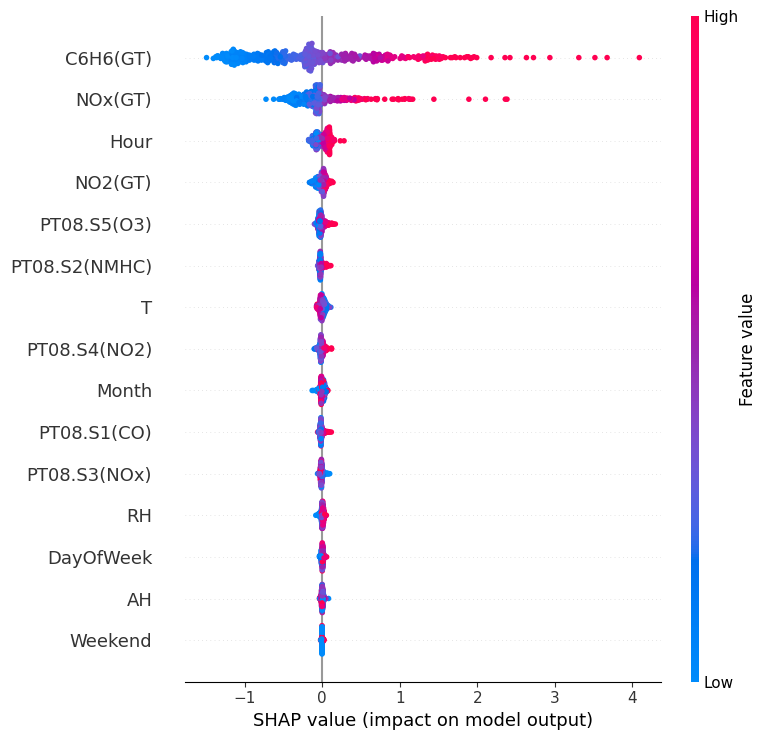

In [ ]:
# RQ4: Do explanations produced by feature-importance methods remain stable when environmental data quality deteriorates?
shap.summary_plot(
    shap_values_noisy,
    X_sample
)

In [ ]:
### RQ4 Findings
"""
The SHAP analysis revealed that feature importance rankings changed after introducing 20% Gaussian noise. 
While the overall predictive performance remained relatively high, several variables shifted in importance.
PT08.S2(NMHC), which was the most influential feature in the clean dataset, lost importance under noisy conditions.
However, key pollutant-related variables such as C6H6(GT), NOx(GT), and NO2(GT) remained consistently important. 
These findings suggest that model explanations are moderately sensitive to deteriorating data quality.
"""

In [ ]:
#RQ5: Can data-quality mitigation strategies restore trustworthiness under severe data degradation?
